# DMP Bridge — Model Comparison (pdfplumber parser)

Comparing three LLM models on structured DMP extraction quality, scored **two ways**:

- **Path A** — against the original ("old") manually-labeled ground truth
- **Path B** — against the newer annotation standard, via an annotation-conversion rule

**Samples:** 3–10 (8 documents; samples 1 & 2 excluded — used for prompt development)

## How the pipeline works

Every model prediction shown below went through the same four steps before it ever reaches this notebook:

```
PDF file
   |
   v
1. Extraction (pdfplumber)        Turns the PDF into text blocks, line by line,
   |                              with position, font size, and bold/italic flags.
   v
2. LLM classification (Ollama)    One model call labels every block:
   |                              title / section.title / section.description /
   |                              question.text / answer.text
   v
3. Structured JSON (converter)    Labeled blocks are nested into the DMP Tool
   |                              schema: narrative -> template -> section[] ->
   |                              question[] -> answer
   v
4. Evaluation  ---------------+-------------------------------+
                              |                                |
                    PATH A: old annotation           PATH B: new annotation
                    (this notebook, below)           (this notebook, below)
                              |                                |
                    Score the structured JSON         Apply the annotation-
                    directly against                  conversion rule ->
                    ground_truth_old_version/          "final JSON" -> score
                                                        against ground_truth_
                                                        new_version/
```

**Path A** scores Step 3's structured JSON directly against the original ground truth — no conversion step. Uses `dmpbridge.evaluation.evaluate.load_method()`.

**Path B** adds one step first: `annotation_rules.apply_new_annotation_rules()` fills in empty `question.text` fields (from the section's own title, or the document title as a fallback), producing "final JSON" for each prediction, which is then scored against the new ground truth. This rule was derived by diffing the old and new ground-truth files sample by sample, and validated to reproduce the real new-version annotation exactly on 4 of 10 samples (full derivation in `annotation_conversion_test.ipynb`, including the one known pattern the rule does *not* cover). Uses `dmpbridge.evaluation.annotation_rules.load_method()`.

Both paths reuse the *same* matching/scoring engine underneath (`_match_structured`, `compute_f1_rows`, `micro_prf1`, ...) — the only difference is which ground truth and which (possibly rule-converted) prediction go into it.

## Setup

In [1]:
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old,
    micro_prf1, compute_f1_rows, confusion_matrix_df,
)
from dmpbridge.evaluation.annotation_rules import (
    convert_tag_to_final,
    load_method_new,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MODELS = [
    ("llama3.1:8b",  "llama3.1-8b_pdfplumber_whole_doc"),
    ("llama3.3:70b", "llama3.3-70b_pdfplumber_whole_doc"),
    ("gemma4:e4b",   "gemma4-e4b_pdfplumber_whole_doc"),
]
EXCLUDE = [1, 2]
COLORS  = ['#1d4ed8', '#60a5fa', '#34d399']

---
# Path A — Evaluation against the OLD annotation

Structured JSON scored directly against `data/input/ground_truth_old_version/` — no conversion step.

In [2]:
results_a = {}
summary_a_rows = []
for display_name, tag in MODELS:
    df, conf, errs = load_method_old(tag, exclude=EXCLUDE)
    if df is None:
        print(f'{display_name:15s} : no data yet')
        continue
    results_a[display_name] = {'df': df, 'conf': conf, 'tag': tag}
    m = micro_prf1(conf)
    summary_a_rows.append({'model': display_name, **m})

summary_a = pd.DataFrame(summary_a_rows).set_index('model')

print(f"{'Model':<15}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print('-' * 46)
for name, row in summary_a.iterrows():
    print(f"{name:<15}  {row['precision']*100:>9.1f}%  {row['recall']*100:>7.1f}%  {row['f1']*100:>7.1f}%")

Model             Precision    Recall        F1
----------------------------------------------
llama3.1:8b           32.3%     80.0%     46.0%
llama3.3:70b          68.9%     81.1%     74.5%
gemma4:e4b            72.4%     78.9%     75.5%


## Path A: Overall Comparison

Precision drops when a model over-generates spurious blocks; recall drops when it misses gold items. **F1 balances both — this is the single number to compare models on.**

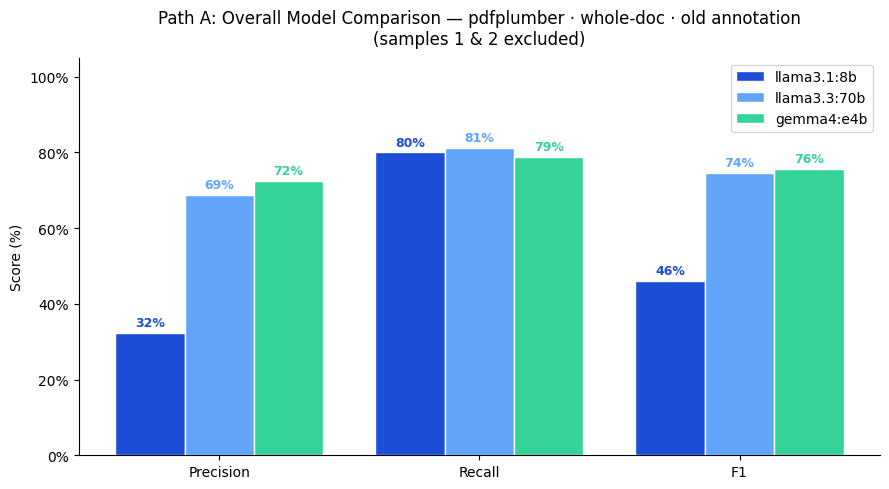

In [3]:
metrics = ['precision', 'recall', 'f1']
metric_labels = ['Precision', 'Recall', 'F1']
n_models = len(summary_a)
w = 0.8 / n_models
xi = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(summary_a.index, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    vals = [summary_a.loc[name, m] * 100 for m in metrics]
    bars = ax.bar([x + offset for x in xi], vals, width=w,
                  label=name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Path A: Overall Model Comparison — pdfplumber · whole-doc · old annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path A Detail: F1 Score per Label

Label                        llama3.1:8b   llama3.3:70b     gemma4:e4b
----------------------------------------------------------------------
title                             100.0%         100.0%          93.3%
section.title                      74.0%          75.7%          75.4%
section.description                33.3%          57.1%          40.0%
question.text                       2.5%           0.0%          50.0%
answer.text                        51.1%          80.5%          84.9%


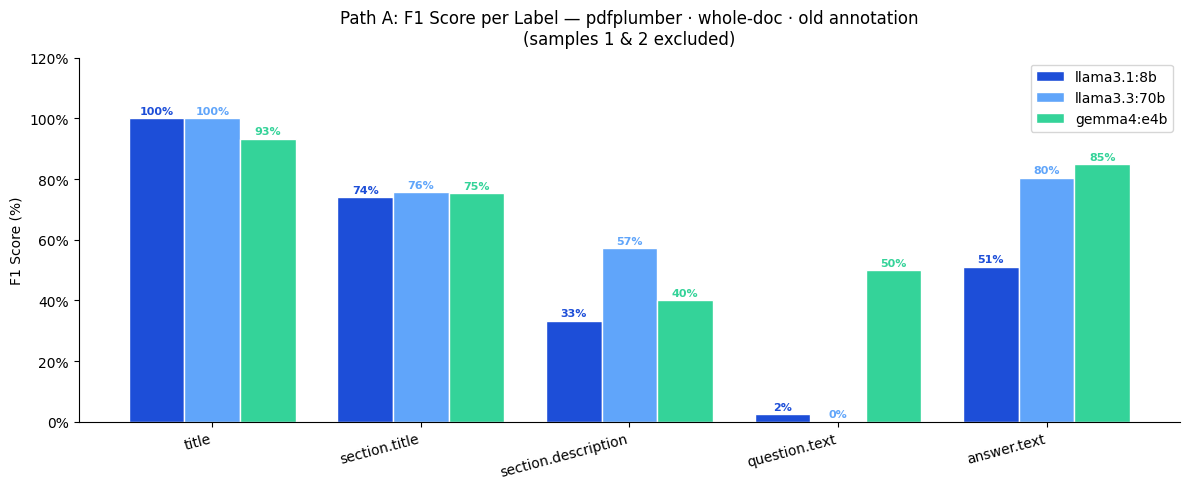

In [4]:
f1_data_a = {}
for name, res in results_a.items():
    f1_data_a[name] = compute_f1_rows(res['conf']).set_index('label')['f1']

df_f1_a = pd.DataFrame(f1_data_a) * 100

print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1_a.columns))
print('-' * (25 + 15 * len(df_f1_a.columns)))
for label, row in df_f1_a.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

n_models = len(df_f1_a.columns)
n_labels = len(df_f1_a)
w = 0.8 / n_models
xi = range(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1_a.columns, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1_a[name], width=w,
                  label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, df_f1_a[name]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1_a.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Path A: F1 Score per Label — pdfplumber · whole-doc · old annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path A Detail: Confusion Matrix per Model
Rows = true label · Columns = predicted label

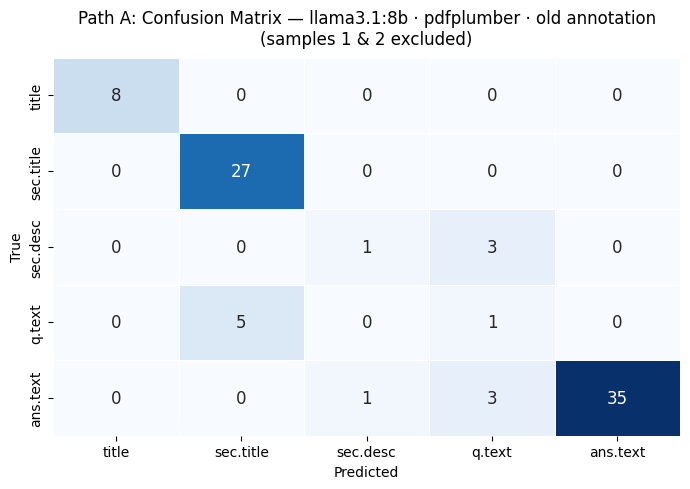

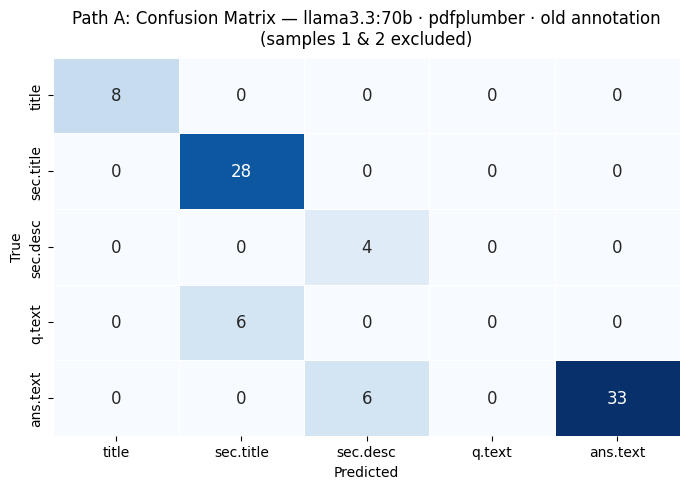

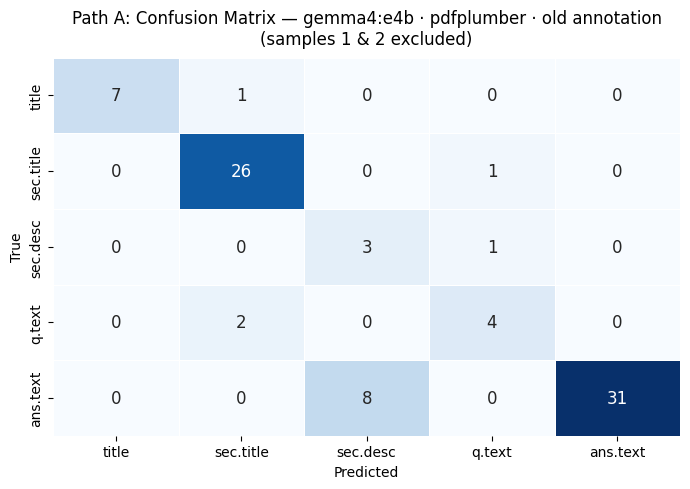

In [5]:
for name, res in results_a.items():
    mat = confusion_matrix_df(res['conf']).drop(columns=['missed'])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                linecolor='white', ax=ax, cbar=False, annot_kws={'size': 12})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Path A: Confusion Matrix — {name} · pdfplumber · old annotation\n(samples 1 & 2 excluded)', pad=10)
    plt.tight_layout()
    plt.show()

---
# Path B — Evaluation against the NEW annotation

Step 1: apply the annotation-conversion rule to every model's structured JSON, producing "final JSON". Step 2: score that final JSON against `data/input/ground_truth_new_version/`.

In [6]:
for _, tag in MODELS:
    n = convert_tag_to_final(tag)
    print(f'{tag:<38} {n} file(s) -> final JSON')

llama3.1-8b_pdfplumber_whole_doc       10 file(s) -> final JSON
llama3.3-70b_pdfplumber_whole_doc      10 file(s) -> final JSON
gemma4-e4b_pdfplumber_whole_doc        10 file(s) -> final JSON


In [7]:
results_b = {}
summary_b_rows = []
for display_name, tag in MODELS:
    df, conf, errs = load_method_new(tag, exclude=EXCLUDE)
    if df is None:
        print(f'{display_name:15s} : no data yet')
        continue
    results_b[display_name] = {'df': df, 'conf': conf, 'tag': tag}
    m = micro_prf1(conf)
    summary_b_rows.append({'model': display_name, **m})

summary_b = pd.DataFrame(summary_b_rows).set_index('model')

print(f"{'Model':<15}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print('-' * 46)
for name, row in summary_b.iterrows():
    print(f"{name:<15}  {row['precision']*100:>9.1f}%  {row['recall']*100:>7.1f}%  {row['f1']*100:>7.1f}%")

Model             Precision    Recall        F1
----------------------------------------------
llama3.1:8b           28.3%     79.7%     41.7%
llama3.3:70b          61.3%     82.3%     70.3%
gemma4:e4b            60.2%     74.7%     66.7%


## Path B: Overall Comparison

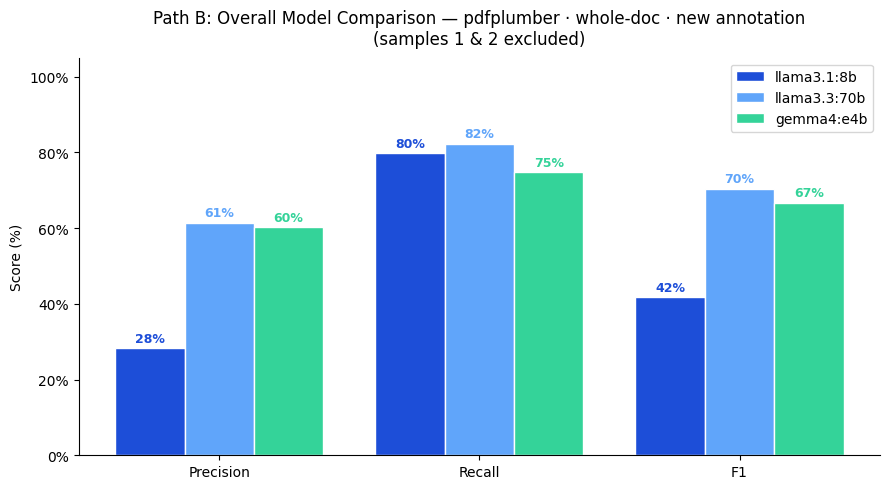

In [8]:
n_models = len(summary_b)
w = 0.8 / n_models
xi = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(summary_b.index, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    vals = [summary_b.loc[name, m] * 100 for m in metrics]
    bars = ax.bar([x + offset for x in xi], vals, width=w,
                  label=name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Path B: Overall Model Comparison — pdfplumber · whole-doc · new annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path B Detail: F1 Score per Label

Label                        llama3.1:8b   llama3.3:70b     gemma4:e4b
----------------------------------------------------------------------
title                             100.0%         100.0%          90.9%
section.title                      74.0%          75.7%          75.4%
section.description                33.3%          57.1%          40.0%
question.text                       5.1%          50.0%          28.6%
answer.text                        40.9%          64.9%          67.6%


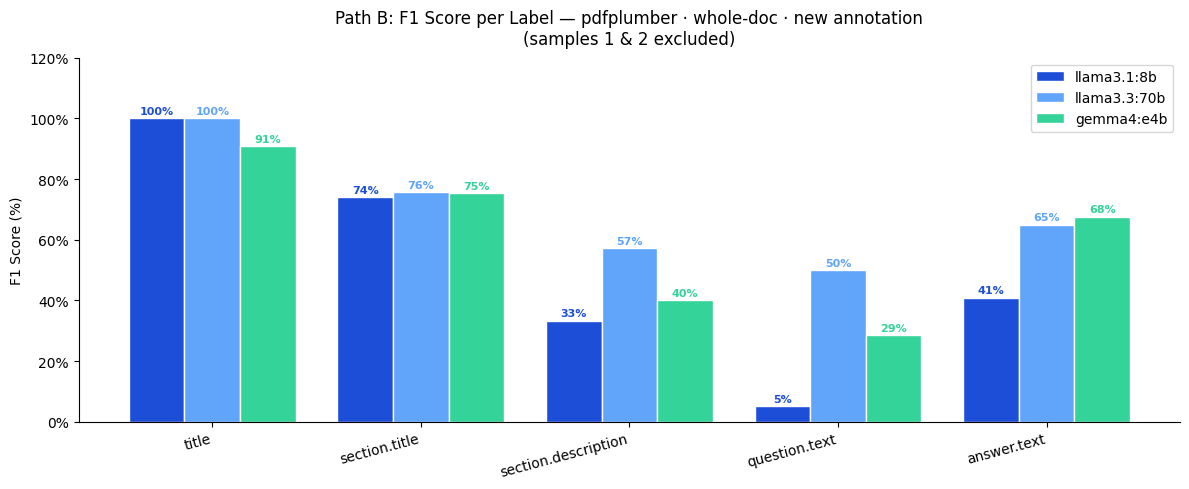

In [9]:
f1_data_b = {}
for name, res in results_b.items():
    f1_data_b[name] = compute_f1_rows(res['conf']).set_index('label')['f1']

df_f1_b = pd.DataFrame(f1_data_b) * 100

print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1_b.columns))
print('-' * (25 + 15 * len(df_f1_b.columns)))
for label, row in df_f1_b.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

n_models = len(df_f1_b.columns)
n_labels = len(df_f1_b)
w = 0.8 / n_models
xi = range(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1_b.columns, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1_b[name], width=w,
                  label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, df_f1_b[name]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1_b.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Path B: F1 Score per Label — pdfplumber · whole-doc · new annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path B Detail: Confusion Matrix per Model
Rows = true label · Columns = predicted label

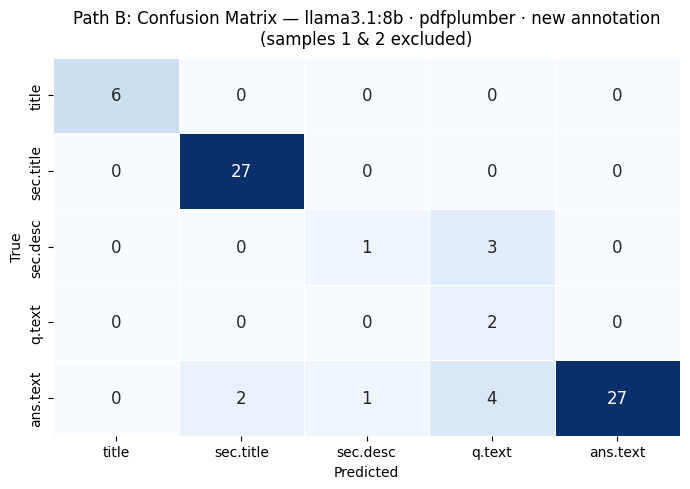

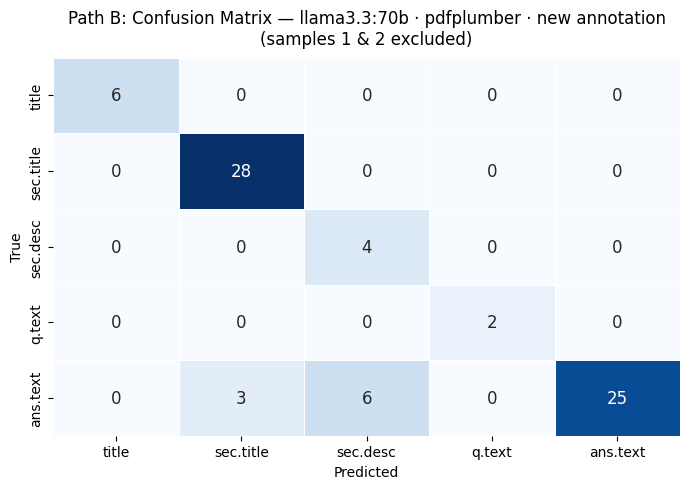

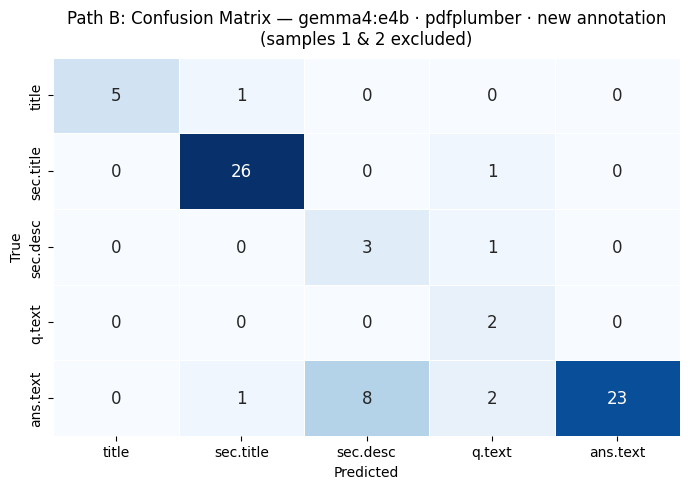

In [10]:
for name, res in results_b.items():
    mat = confusion_matrix_df(res['conf']).drop(columns=['missed'])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                linecolor='white', ax=ax, cbar=False, annot_kws={'size': 12})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Path B: Confusion Matrix — {name} · pdfplumber · new annotation\n(samples 1 & 2 excluded)', pad=10)
    plt.tight_layout()
    plt.show()